In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import subprocess
subprocess.run(['pip', 'install', 'shap', '--quiet', '--break-system-packages'],
               capture_output=True)
print('shap ready')

shap ready


In [ ]:
import os
import pickle
import numpy as np
import shap
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit

DATA_PATH  = '/content/drive/MyDrive/GAMEEMO_processed/gameemo_preprocessed.pkl'
MODEL_PATH = '/content/drive/MyDrive/GAMEEMO_processed/results/cnn1d_cross_subject_best.keras'
SAVE_DIR   = '/content/drive/MyDrive/GAMEEMO_processed/figures'
os.makedirs(SAVE_DIR, exist_ok=True)

with open(DATA_PATH, 'rb') as f:
    data = pickle.load(f)

X            = data['X']
y            = data['y']
subject_ids  = data['subject_ids']
label_names  = data['label_names']
n_classes    = len(label_names)
channel_names = ['AF3','F7','F3','FC5','T7','P7','O1','O2','P8','T8','FC6','F4','F8','AF4']

print('X shape      :', X.shape)
print('label names  :', label_names)
print('channel names:', channel_names)

X shape      : (8288, 512, 14)
label names  : ['boring', 'calm', 'horror', 'funny']
channel names: ['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1', 'O2', 'P8', 'T8', 'FC6', 'F4', 'F8', 'AF4']


In [ ]:
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(X, y, groups=subject_ids))

X_train = X[train_idx]
X_test  = X[test_idx]
y_test  = y[test_idx]

print('train subjects :', np.unique(subject_ids[train_idx]))
print('test subjects  :', np.unique(subject_ids[test_idx]))
print('train size     :', X_train.shape)
print('test size      :', X_test.shape)

train subjects : [ 2  3  4  5  6  7  8 11 12 14 15 16 17 18 19 20 21 23 24 25 27 28]
test subjects  : [ 1  9 10 13 22 26]
train size     : (6512, 512, 14)
test size      : (1776, 512, 14)


In [ ]:
model = tf.keras.models.load_model(MODEL_PATH)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
acc = np.mean(y_pred == y_test)
print(f'cross-subject test accuracy: {acc:.4f}')
print('model loaded successfully')

cross-subject test accuracy: 0.9825
model loaded successfully


In [ ]:
np.random.seed(42)

bg_idx = np.random.choice(len(X_train), 100, replace=False)
background = X_train[bg_idx]

test_sample_idx = np.random.choice(len(X_test), 200, replace=False)
X_explain = X_test[test_sample_idx]
y_explain = y_test[test_sample_idx]

print('background shape :', background.shape)
print('X_explain shape  :', X_explain.shape)

background shape : (100, 512, 14)
X_explain shape  : (200, 512, 14)


In [ ]:
explainer   = shap.GradientExplainer(model, background)
shap_values = explainer.shap_values(X_explain)

sv_full = np.array(shap_values)
print('shap_values shape:', sv_full.shape)
# confirmed shape: (200, 512, 14, 4) = (samples, time, channels, classes)

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_3
Received: inputs=['Tensor(shape=(200, 512, 14))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_3
Received: inputs=['Tensor(shape=(50, 512, 14))']
  warnings.warn(msg)


shap_values shape: (200, 512, 14, 4)


In [ ]:
sv_full = np.array(shap_values)
# shape: (200, 512, 14, 4) = (samples, time, channels, classes)

channel_importance = np.zeros((n_classes, len(channel_names)))

for cls in range(n_classes):
    sv = np.abs(sv_full[:, :, :, cls])       # (200, 512, 14)
    mean_over_time = sv.mean(axis=1)          # (200, 14)
    channel_importance[cls] = mean_over_time.mean(axis=0)  # (14,)

print('channel importance shape:', channel_importance.shape)
print()
for cls in range(n_classes):
    top3 = np.argsort(channel_importance[cls])[::-1][:3]
    print(f'{label_names[cls]:10s} top 3 channels: {[channel_names[i] for i in top3]}')

channel importance shape: (4, 14)

boring     top 3 channels: ['F8', 'AF4', 'FC5']
calm       top 3 channels: ['T8', 'AF4', 'FC5']
horror     top 3 channels: ['T8', 'AF4', 'FC5']
funny      top 3 channels: ['T8', 'FC5', 'P7']


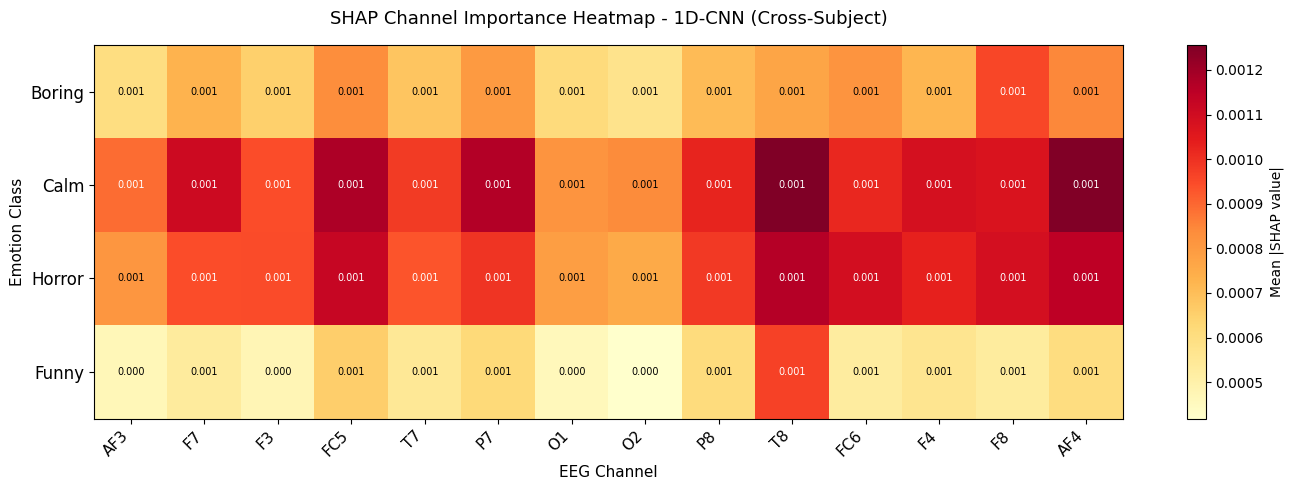

saved: /content/drive/MyDrive/GAMEEMO_processed/figures/shap_cs_channel_heatmap.png


In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))

im = ax.imshow(channel_importance, aspect='auto', cmap='YlOrRd')

ax.set_xticks(range(len(channel_names)))
ax.set_xticklabels(channel_names, rotation=45, ha='right', fontsize=11)
ax.set_yticks(range(n_classes))
ax.set_yticklabels([n.capitalize() for n in label_names], fontsize=12)
ax.set_title('SHAP Channel Importance Heatmap - 1D-CNN (Cross-Subject)', fontsize=13, pad=15)
ax.set_xlabel('EEG Channel', fontsize=11)
ax.set_ylabel('Emotion Class', fontsize=11)
plt.colorbar(im, ax=ax, label='Mean |SHAP value|')

for i in range(n_classes):
    for j in range(len(channel_names)):
        ax.text(j, i, f'{channel_importance[i,j]:.3f}',
                ha='center', va='center', fontsize=7,
                color='black' if channel_importance[i,j] < channel_importance.max()*0.7 else 'white')

plt.tight_layout()
save_path = os.path.join(SAVE_DIR, 'shap_cs_channel_heatmap.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print('saved:', save_path)

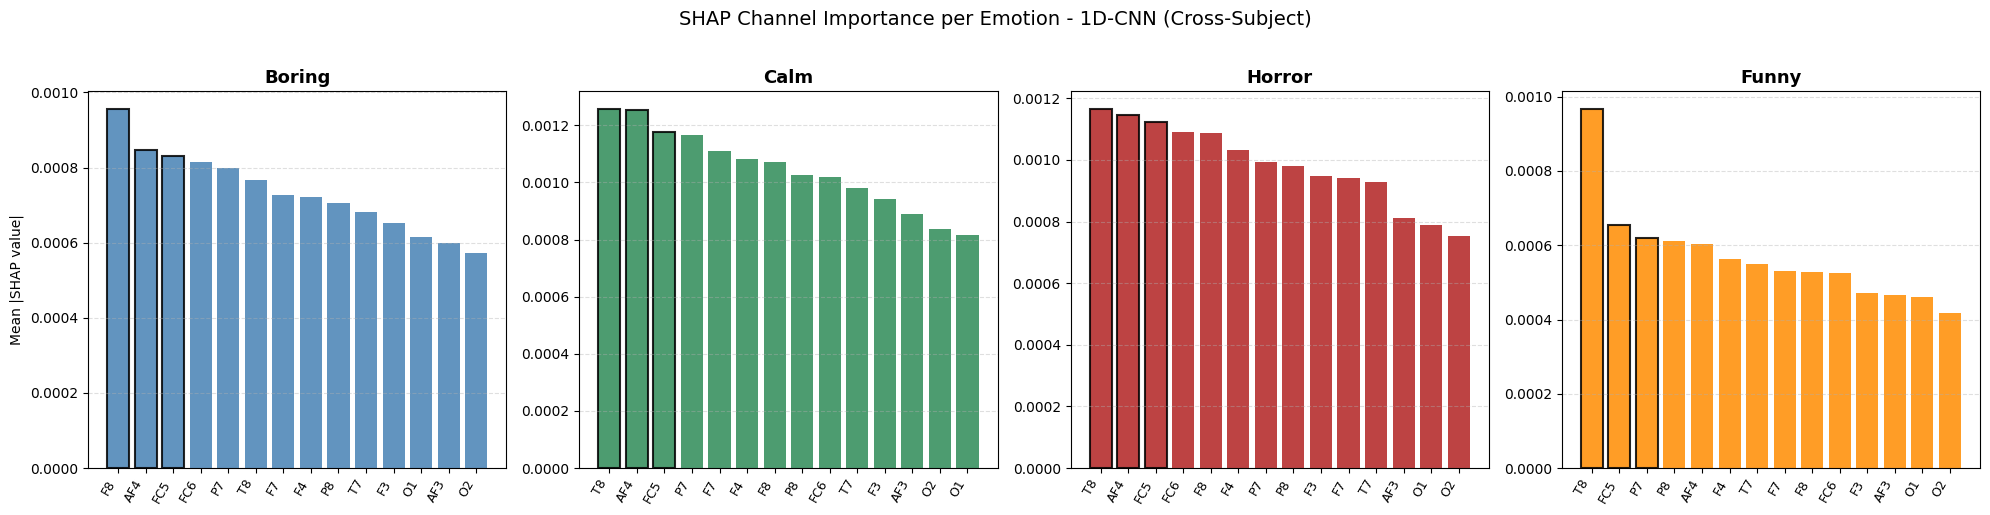

saved: /content/drive/MyDrive/GAMEEMO_processed/figures/shap_cs_per_emotion_bars.png


In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
colors = ['steelblue', 'seagreen', 'firebrick', 'darkorange']

for cls in range(n_classes):
    ax = axes[cls]
    importance  = channel_importance[cls]
    sorted_idx  = np.argsort(importance)[::-1]
    sorted_names = [channel_names[i] for i in sorted_idx]
    sorted_vals  = importance[sorted_idx]

    bars = ax.bar(range(len(channel_names)), sorted_vals, color=colors[cls], alpha=0.85)
    ax.set_xticks(range(len(channel_names)))
    ax.set_xticklabels(sorted_names, rotation=60, ha='right', fontsize=9)
    ax.set_title(label_names[cls].capitalize(), fontsize=13, fontweight='bold')
    ax.set_ylabel('Mean |SHAP value|' if cls == 0 else '')
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    for i in range(3):
        bars[i].set_edgecolor('black')
        bars[i].set_linewidth(1.5)

fig.suptitle('SHAP Channel Importance per Emotion - 1D-CNN (Cross-Subject)', fontsize=14, y=1.02)
plt.tight_layout()
save_path = os.path.join(SAVE_DIR, 'shap_cs_per_emotion_bars.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print('saved:', save_path)

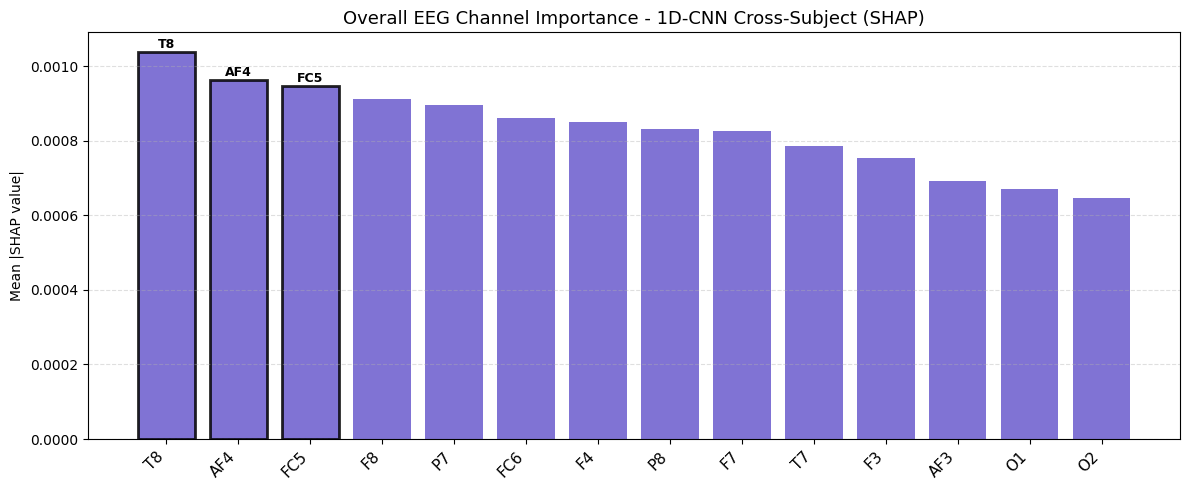

saved: /content/drive/MyDrive/GAMEEMO_processed/figures/shap_cs_overall_importance.png

top 5 most important channels overall:
  1. T8      importance: 0.00104
  2. AF4     importance: 0.00096
  3. FC5     importance: 0.00095
  4. F8      importance: 0.00091
  5. P7      importance: 0.00089


In [ ]:
overall_importance = channel_importance.mean(axis=0)
sorted_idx = np.argsort(overall_importance)[::-1]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(range(len(channel_names)),
              overall_importance[sorted_idx],
              color='slateblue', alpha=0.85)

ax.set_xticks(range(len(channel_names)))
ax.set_xticklabels([channel_names[i] for i in sorted_idx], rotation=45, ha='right', fontsize=11)
ax.set_title('Overall EEG Channel Importance - 1D-CNN Cross-Subject (SHAP)', fontsize=13)
ax.set_ylabel('Mean |SHAP value|')
ax.grid(axis='y', linestyle='--', alpha=0.4)

for i in range(3):
    bars[i].set_edgecolor('black')
    bars[i].set_linewidth(2)
    ax.text(i, overall_importance[sorted_idx][i] + overall_importance.max()*0.01,
            channel_names[sorted_idx[i]], ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
save_path = os.path.join(SAVE_DIR, 'shap_cs_overall_importance.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print('saved:', save_path)

print()
print('top 5 most important channels overall:')
for i in range(5):
    print(f'  {i+1}. {channel_names[sorted_idx[i]]:6s}  importance: {overall_importance[sorted_idx[i]]:.5f}')

horror_shap_mean shape: (200, 14)
X_explain_mean shape  : (200, 14)


/tmp/ipykernel_716/1510664582.py:12: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


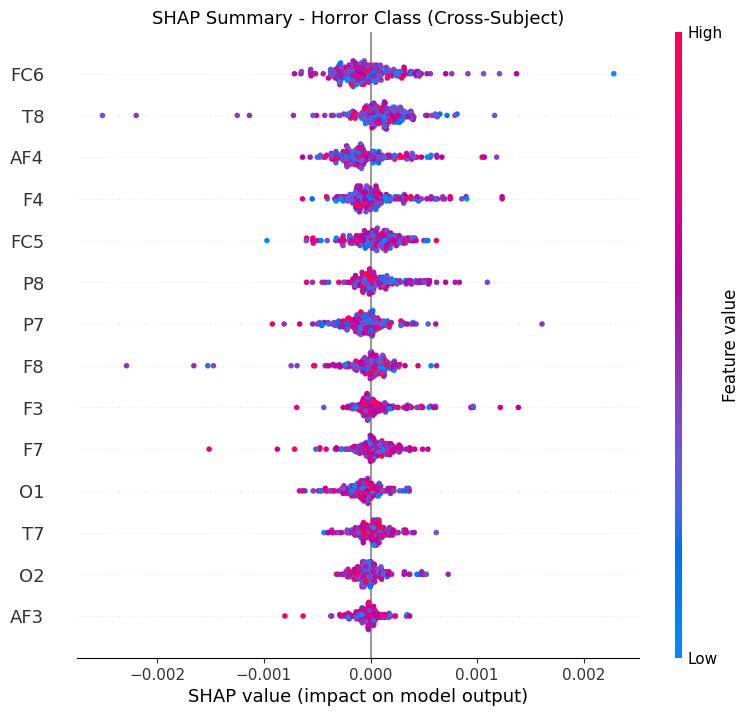

saved: /content/drive/MyDrive/GAMEEMO_processed/figures/shap_cs_summary_horror.png


In [ ]:
sv_full = np.array(shap_values)
# shape: (200, 512, 14, 4)

horror_shap      = sv_full[:, :, :, 2]           # (200, 512, 14) - class 2 = horror
horror_shap_mean = horror_shap.mean(axis=1)       # (200, 14) - average over time
X_explain_mean   = X_explain.mean(axis=1)         # (200, 14) - average over time

print('horror_shap_mean shape:', horror_shap_mean.shape)
print('X_explain_mean shape  :', X_explain_mean.shape)

plt.figure(figsize=(10, 6))
shap.summary_plot(
    horror_shap_mean,
    X_explain_mean,
    feature_names=channel_names,
    show=False,
)
plt.title('SHAP Summary - Horror Class (Cross-Subject)', fontsize=13)
save_path = os.path.join(SAVE_DIR, 'shap_cs_summary_horror.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print('saved:', save_path)

In [ ]:
try:
    import mne
    print(f"mne is installed — version {mne.__version__}")
except ImportError:
    print("mne not found, installing...")
    !pip install mne -q
    import mne
    print(f"mne installed — version {mne.__version__}")

mne not found, installing...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 56.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.
mne installed — version 1.12.1


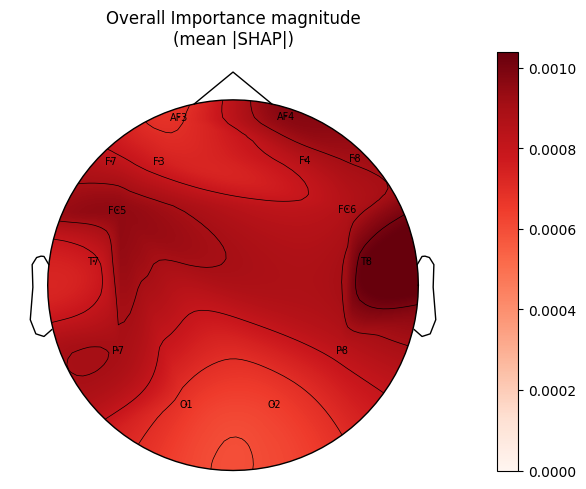

In [ ]:
import mne

montage = mne.channels.make_standard_montage('standard_1020')
info = mne.create_info(ch_names=channel_names, sfreq=128, ch_types='eeg')
info.set_montage(montage)

fig, axes = plt.subplots(figsize=(11, 5))

im1, _ = mne.viz.plot_topomap(
    overall_importance, info,axes=axes, show=False,
    cmap='Reds', contours=4, names=channel_names
)
axes.set_title('Overall Importance magnitude\n(mean |SHAP|)')
plt.colorbar(im1, ax=axes, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [ ]:
shap_output = {
    'shap_values'       : shap_values,
    'channel_importance': channel_importance,
    'overall_importance': overall_importance,
    'channel_names'     : channel_names,
    'label_names'       : label_names,
    'y_explain'         : y_explain,
    'protocol'          : 'cross_subject'
}

with open(os.path.join(SAVE_DIR, 'shap_cs_results.pkl'), 'wb') as f:
    pickle.dump(shap_output, f)

print('all results saved to', SAVE_DIR)

all results saved to /content/drive/MyDrive/GAMEEMO_processed/figures
